In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
website = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE169nnn/GSE169598/matrix/GSE169598_series_matrix.txt.gz"
data_path = "fajciarky_data/data.txt"
data_path_zip = "fajciarky_data/data.txt.gz"

In [4]:

!curl $website --create-dirs -o $data_path_zip
!gunzip $data_path_zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  333M  100  333M    0     0  14.2M      0  0:00:23  0:00:23 --:--:-- 14.2M


In [5]:
skiprow = None

with open(data_path, "r") as f:

    for i, line in enumerate(f):

        if line.startswith("\"ID_REF\""):
            skiprow = i
            break

print("Table starts at row:", skiprow)

Table starts at row: 64


In [6]:
df = pd.read_csv(
    data_path,
    sep="\t",
    comment="!",
    header=0,
    skiprows=skiprow
)

df.set_index("ID_REF", inplace=True)

print("\nOriginal shape:")
print(df.shape)


Original shape:
(714666, 96)


In [7]:
print("\nFirst rows:")
print(df.head())



First rows:
            GSM5210464  GSM5210465  GSM5210466  GSM5210467  GSM5210468  \
ID_REF                                                                   
cg00000029    0.006342    0.101510    0.042916    0.101567    0.114736   
cg00000109    0.911428    0.924547    0.926018    0.920207    0.925702   
cg00000155    0.948963    0.936607    0.946371    0.951434    0.949158   
cg00000158    0.955034    0.954614    0.964843    0.958018    0.954761   
cg00000165    0.602739    0.654239    0.635608    0.514626    0.569226   

            GSM5210469  GSM5210470  GSM5210471  GSM5210472  GSM5210473  ...  \
ID_REF                                                                  ...   
cg00000029    0.129332    0.134621    0.105126    0.116374    0.115263  ...   
cg00000109    0.920111    0.928904    0.930301    0.936867    0.929511  ...   
cg00000155    0.941937    0.940608    0.952269    0.940826    0.945244  ...   
cg00000158    0.952986    0.948309    0.949837    0.964955    0.958335  .

In [8]:
df = df.astype(float)

df = df.T

print("\nTransposed shape:")
print(df.shape)


Transposed shape:
(96, 714666)


In [9]:
print("\nFirst rows after transpose:")
print(df.head())


First rows after transpose:
ID_REF      cg00000029  cg00000109  cg00000155  cg00000158  cg00000165  \
GSM5210464    0.006342    0.911428    0.948963    0.955034    0.602739   
GSM5210465    0.101510    0.924547    0.936607    0.954614    0.654239   
GSM5210466    0.042916    0.926018    0.946371    0.964843    0.635608   
GSM5210467    0.101567    0.920207    0.951434    0.958018    0.514626   
GSM5210468    0.114736    0.925702    0.949158    0.954761    0.569226   

ID_REF      cg00000221  cg00000236  cg00000289  cg00000292  cg00000321  ...  \
GSM5210464    0.919096    0.829139    0.854049    0.640229    0.568796  ...   
GSM5210465    0.912881    0.864159    0.833509    0.706422    0.642472  ...   
GSM5210466    0.915767    0.825087    0.844758    0.597064    0.607435  ...   
GSM5210467    0.910884    0.828211    0.776141    0.575917    0.461922  ...   
GSM5210468    0.908985    0.819156    0.792884    0.680974    0.634972  ...   

ID_REF      cg27665860  cg27665913  cg27665925  cg2

In [10]:
metadata = {}

with open(data_path, "r") as file:

    characteristic_counter = 0

    for line in file:
        if line.startswith("!Sample_title"):

            metadata["title"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_geo_accession"):

            metadata["accession"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_characteristics_ch1"):

            values = line.strip().split("\t")[1:]
            
            if characteristic_counter == 0:
                metadata["sex"] = values
            elif characteristic_counter == 1:
                metadata["gestational_age"] = values
            elif characteristic_counter == 2:
                metadata["smoke_type"] = values

            characteristic_counter += 1
        elif line.startswith("!series_matrix_table_begin"):
            break

meta_df = pd.DataFrame(metadata)
meta_df = meta_df.applymap(lambda x: x.replace('"', ''))
print(meta_df.columns)

Index(['title', 'accession', 'sex', 'gestational_age', 'smoke_type'], dtype='object')


/var/folders/9c/cghhh9pn5tx01rr31vbtfjkw0000gn/T/ipykernel_34283/1541953412.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  meta_df = meta_df.applymap(lambda x: x.replace('"', ''))


In [11]:
print(meta_df.head())


             title   accession     sex              gestational_age  \
0  placental DNA 1  GSM5210464  Sex: F  gestational age weeks: 39.4   
1  placental DNA 2  GSM5210465  Sex: F  gestational age weeks: 39.3   
2  placental DNA 3  GSM5210466  Sex: F  gestational age weeks: 39.3   
3  placental DNA 4  GSM5210467  Sex: M  gestational age weeks: 39.7   
4  placental DNA 5  GSM5210468  Sex: F  gestational age weeks: 37.7   

           smoke_type  
0  smoking: nonsmoker  
1     smoking: smoker  
2  smoking: nonsmoker  
3     smoking: smoker  
4     smoking: smoker  


In [12]:
for col in meta_df.columns:

    print("COLUMN:", col)

    print(meta_df[col].unique()[:20])

COLUMN: title
['placental DNA 1' 'placental DNA 2' 'placental DNA 3' 'placental DNA 4'
 'placental DNA 5' 'placental DNA 6' 'placental DNA 7' 'placental DNA 8'
 'placental DNA 9' 'placental DNA 10' 'placental DNA 11'
 'placental DNA 12' 'placental DNA 13' 'placental DNA 14'
 'placental DNA 15' 'placental DNA 16' 'placental DNA 17'
 'placental DNA 18' 'placental DNA 19' 'placental DNA 20']
COLUMN: accession
['GSM5210464' 'GSM5210465' 'GSM5210466' 'GSM5210467' 'GSM5210468'
 'GSM5210469' 'GSM5210470' 'GSM5210471' 'GSM5210472' 'GSM5210473'
 'GSM5210474' 'GSM5210475' 'GSM5210476' 'GSM5210477' 'GSM5210478'
 'GSM5210479' 'GSM5210489' 'GSM5210490' 'GSM5210491' 'GSM5210492']
COLUMN: sex
['Sex: F' 'Sex: M']
COLUMN: gestational_age
['gestational age weeks: 39.4' 'gestational age weeks: 39.3'
 'gestational age weeks: 39.7' 'gestational age weeks: 37.7'
 'gestational age weeks: 38.4' 'gestational age weeks: 38.1'
 'gestational age weeks: 38.0' 'gestational age weeks: 42.4'
 'gestational age weeks: 

In [13]:
def create_label(smoke_value):

    value = smoke_value.lower()

    if "nonsmoker" in value:
        return "NonSmoker"

    elif "smoker" in value:
        return "Smoker"

    else:
        return "Unknown"
    
meta_df["label"] = meta_df["smoke_type"].apply(create_label)

print("\nLabel counts:")
print(meta_df["label"].value_counts())


Label counts:
label
Smoker       72
NonSmoker    24
Name: count, dtype: int64


In [14]:
meta_df = meta_df.set_index("accession")

y = meta_df.loc[df.index, "label"]

X = df.copy()

print(X.shape)
print(y.value_counts())

(96, 714666)
label
Smoker       72
NonSmoker    24
Name: count, dtype: int64


In [16]:
variances = X.var(axis=0)

top_features = variances.sort_values(ascending=False).head(10000).index

X_filtered = X[top_features]

print("\nAfter feature filtering:")
print(X_filtered.shape)


After feature filtering:
(96, 10000)


In [17]:
"""from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

X_small = X_filtered

model = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=25,
    direction="forward",
    scoring="accuracy",
    cv=2,
    n_jobs=-1
)

sfs.fit(X_small, y)

X_selected = sfs.transform(X_small)

print("Selected shape:", X_selected.shape)"""
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

X_small = X_filtered

selector = SelectKBest(score_func=f_classif, k=100)

X_selected = selector.fit_transform(X_small, y)

print("Selected shape:", X_selected.shape)

Selected shape: (96, 100)


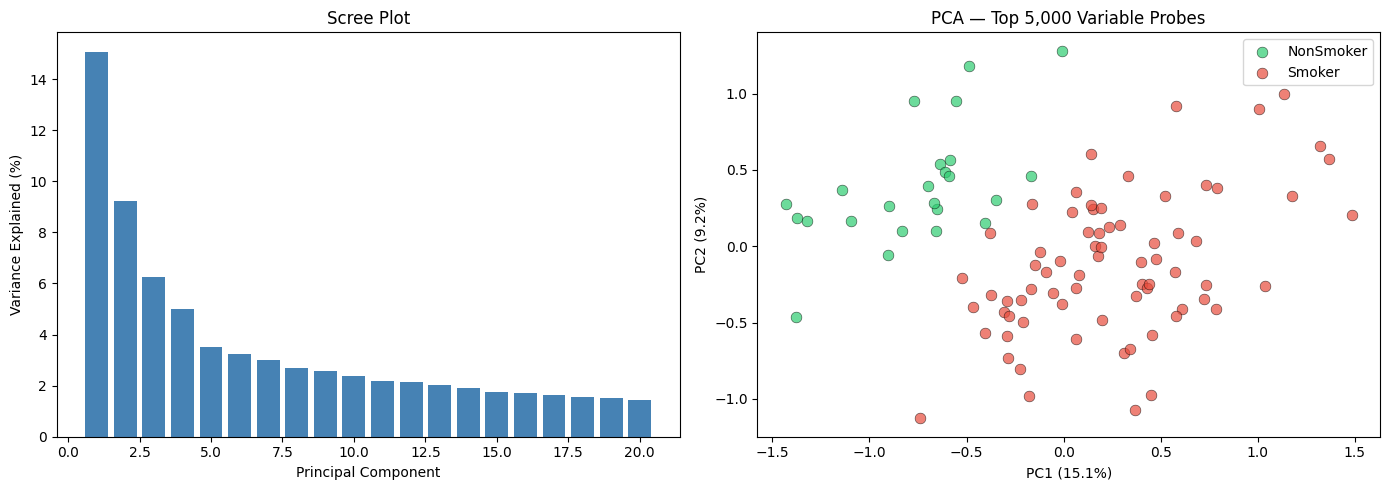

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, random_state=42)
#pca = PCA(n_components=0.95, random_state=42)
PCs = pca.fit_transform(X_selected)

#scree
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].bar(range(1, 21), pca.explained_variance_ratio_ * 100, color='steelblue')
#axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')

#pc1 vs pc2
colors = {'Smoker': '#e74c3c', 'NonSmoker': '#2ecc71'}
for label, grp in pd.DataFrame({'PC1': PCs[:,0], 'PC2': PCs[:,1], 'label': y.values}).groupby('label'):
    axes[1].scatter(grp['PC1'], grp['PC2'], label=label,
                    color=colors[label], alpha=0.7, edgecolors='k', linewidths=0.4, s=60)
    
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA — Top 5,000 Variable Probes')

axes[1].legend()

plt.tight_layout()
plt.show()

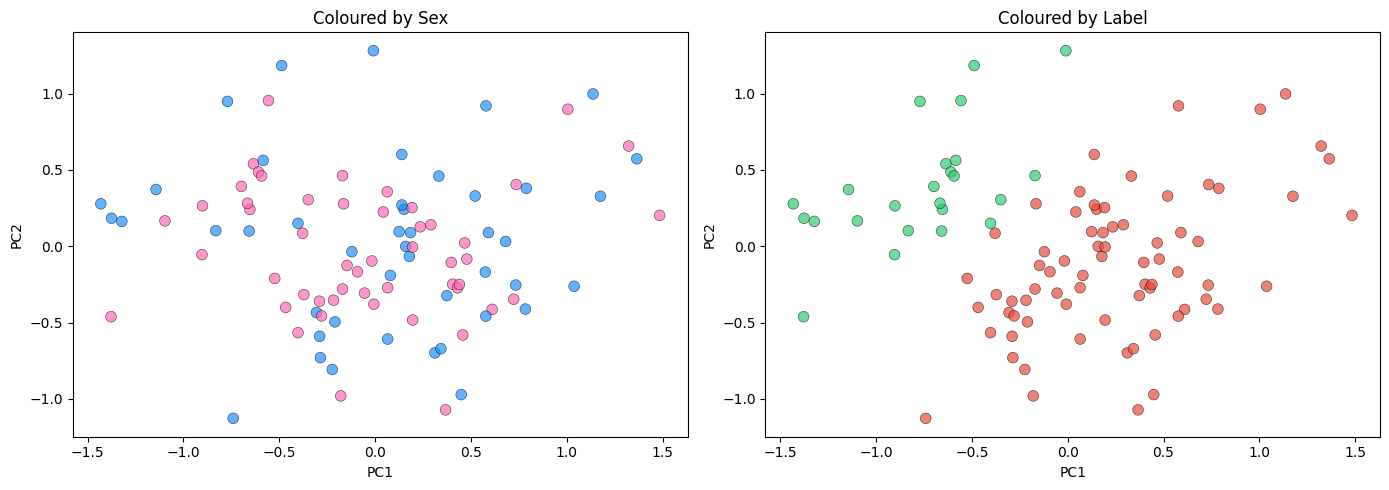

/var/folders/9c/cghhh9pn5tx01rr31vbtfjkw0000gn/T/ipykernel_34283/4126826456.py:24: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60, cmap='viridis')


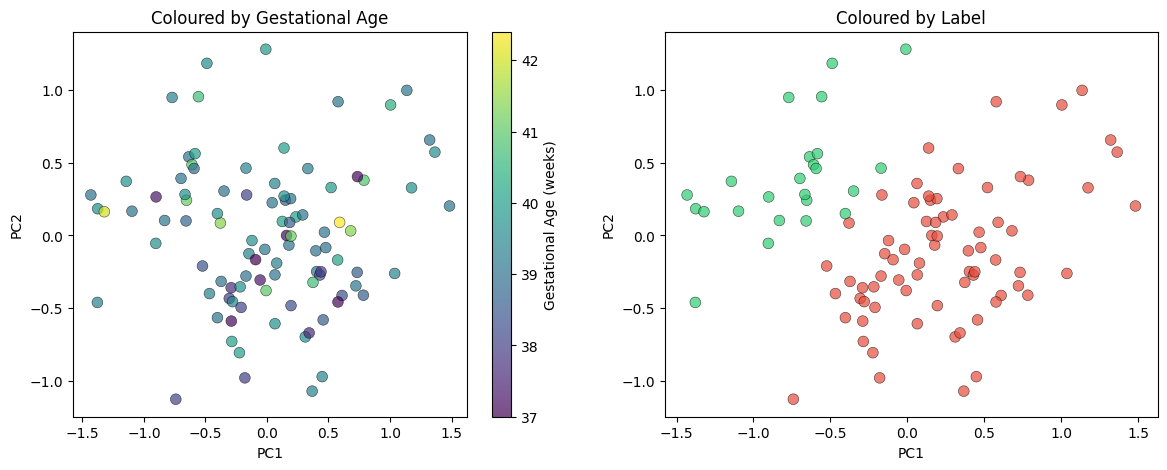

In [ ]:
sex_col = meta_df.loc[df.index, 'sex'].map({'Sex: F': 'hotpink', 'Sex: M': 'dodgerblue'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           [sex_col.values, None],
                           ['Coloured by Sex', 'Coloured by Label']):
    if col is None:
        col = [colors[l] for l in y.values]
    ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60)
    ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
plt.tight_layout()
plt.show()

#by gestational age
age_col = meta_df.loc[df.index, 'gestational_age'].map(
    lambda x: float(x.split(': ')[1].replace(' weeks', ''))
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           [age_col.values, None],
                           ['Coloured by Gestational Age', 'Coloured by Label']):
    if col is None:
        col = [colors[l] for l in y.values]
    scatter = ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60, cmap='viridis')
    ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
    if col is age_col.values:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Gestational Age (weeks)')
        